<a href="https://colab.research.google.com/github/IMnooobdotmineme/GoldGoldGold/blob/main/AI_Gold_Market_Risk_Monitoring_Agent_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Phase 1

In [51]:
!pip install -q yfinance

import yfinance as yf
import pandas as pd
import numpy as np

def get_market_data(start_date="2015-01-01"):
    # Replaced DX-Y.NY with UUP (US Dollar Index ETF)
    tickers = ['GLD', '^GVZ', 'UUP', '^TNX']
    df = yf.download(tickers, start=start_date)['Close'].dropna()

    df['Gold_Return'] = np.log(df['GLD'] / df['GLD'].shift(1))
    df['Gold_Vol'] = df['^GVZ']
    df['USD_Index'] = df['UUP']
    df['Yield_10Y'] = df['^TNX']
    return df[['Gold_Return', 'Gold_Vol', 'USD_Index', 'Yield_10Y']].dropna()

# Test Tool 1
market_data = get_market_data()
print("Data Tool operational! Row count:", len(market_data))

/tmp/ipykernel_2280/3851994463.py:10: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(tickers, start=start_date)['Close'].dropna()
[*********************100%***********************]  4 of 4 completed

Data Tool operational! Row count: 2955


# Phase 2

Training PyTorch GRU Network...
Epoch 10/60 - Loss (MAE): 0.3469
Epoch 20/60 - Loss (MAE): 0.1882
Epoch 30/60 - Loss (MAE): 0.1481
Epoch 40/60 - Loss (MAE): 0.1323
Epoch 50/60 - Loss (MAE): 0.1256
Epoch 60/60 - Loss (MAE): 0.1209


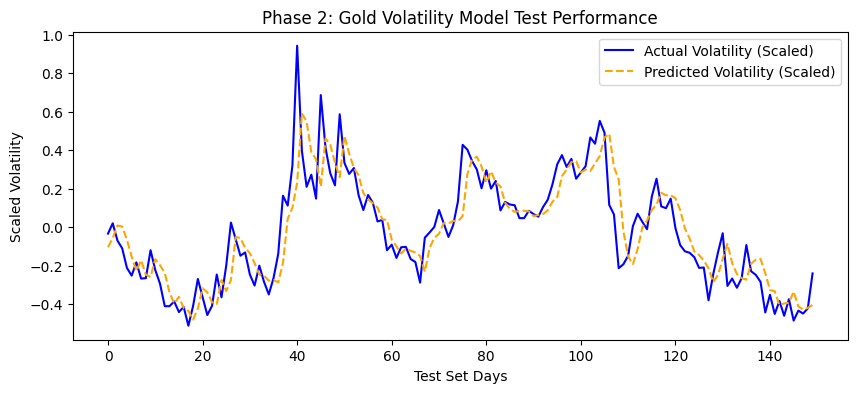

In [52]:
import torch
import torch.nn as nn
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# 1. Standardize All Features
scaler = StandardScaler()
scaled_data = scaler.fit_transform(market_data.values)

# 2. Build 30-Day Sequence Windows
# Target index: Gold_Vol is column index 1
LOOKBACK = 30
X, y = [], []
for i in range(len(scaled_data) - LOOKBACK):
    X.append(scaled_data[i : i + LOOKBACK])
    y.append(scaled_data[i + LOOKBACK, 1])

X = np.array(X)
y = np.array(y)

# 3. Sequential Train/Test Split (80% Train, 20% Test - No Shuffling)
train_size = int(len(X) * 0.8)
X_train = torch.tensor(X[:train_size], dtype=torch.float32)
X_test = torch.tensor(X[train_size:], dtype=torch.float32)
y_train = torch.tensor(y[:train_size], dtype=torch.float32).unsqueeze(1)
y_test = torch.tensor(y[train_size:], dtype=torch.float32).unsqueeze(1)

# 4. Define the GRU Neural Network Architecture
class GoldVolatilityGRU(nn.Module):
    def __init__(self, input_dim=4, hidden_dim=32):
        super().__init__()
        self.gru = nn.GRU(input_size=input_dim, hidden_size=hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        _, h = self.gru(x)
        return self.fc(h[-1])

model = GoldVolatilityGRU()
criterion = nn.L1Loss()  # MAE Loss (robust against outliers)
optimizer = torch.optim.Adam(model.parameters(), lr=0.005)

# 5. Train Model (60 Epochs)
epochs = 60
print("Training PyTorch GRU Network...")
for epoch in range(1, epochs + 1):
    model.train()
    optimizer.zero_grad()
    outputs = model(X_train)
    loss = criterion(outputs, y_train)
    loss.backward()
    optimizer.step()
    if epoch % 10 == 0:
        print(f"Epoch {epoch}/{epochs} - Loss (MAE): {loss.item():.4f}")

# 6. Evaluate Model Predictions
model.eval()
with torch.no_grad():
    predictions = model(X_test).numpy()

# Plot first 150 days of testing predictions vs ground truth
plt.figure(figsize=(10, 4))
plt.plot(y_test.numpy()[:150], label='Actual Volatility (Scaled)', color='blue')
plt.plot(predictions[:150], label='Predicted Volatility (Scaled)', color='orange', linestyle='--')
plt.title("Phase 2: Gold Volatility Model Test Performance")
plt.xlabel("Test Set Days")
plt.ylabel("Scaled Volatility")
plt.legend()
plt.show()

In [53]:
# ==============================================================================
# PHASES 3, 4 & 5: TOOL INTEGRATION AND WORKFLOW ORCHESTRATION
# ==============================================================================

# Tool 2: Volatility Inference Engine
def predict_next_day_volatility(raw_data, trained_model, scaler):
    # Select the most recent 30 trading days of features
    latest_30_days = raw_data.values[-LOOKBACK:]
    scaled_window = scaler.transform(latest_30_days)
    input_tensor = torch.tensor(scaled_window, dtype=torch.float32).unsqueeze(0)

    trained_model.eval()
    with torch.no_grad():
        scaled_pred = trained_model(input_tensor).item()

    # Unscale the prediction back to actual ^GVZ volatility index points
    dummy = np.zeros((1, 4))
    dummy[0, 1] = scaled_pred
    unscaled_pred = scaler.inverse_transform(dummy)[0, 1]

    return unscaled_pred, scaled_pred

# Tool 3: Automated Risk Assessment & Decision Engine
def evaluate_risk_level(predicted_gvz, current_gvz):
    diff = predicted_gvz - current_gvz

    if predicted_gvz >= 22.0 or diff > 2.0:
        risk_status = "HIGH RISK / VOLATILITY SPIKE WARNING"
        recommendation = "Reduce long position size; hedge portfolio using gold put options."
    elif predicted_gvz >= 16.0 or diff > 0.5:
        risk_status = "ELEVATED RISK"
        recommendation = "Monitor order book closely; tighten stop-loss thresholds."
    else:
        risk_status = "NORMAL / LOW RISK"
        recommendation = "Maintain standard position allocations."

    return risk_status, recommendation, diff

# Workflow Orchestrator (Main Agent Execution Controller)
def run_market_risk_agent():
    print("=== EXECUTING AUTONOMOUS MARKET RISK AGENT WORKFLOW ===")

    # 1. Execute Tool 1: Ingest Fresh Market Data
    df = get_market_data()
    current_gvz = df['Gold_Vol'].iloc[-1]
    latest_date = df.index[-1].strftime('%Y-%m-%d')
    print(f"[Tool 1 - Data Fetcher]: Data loaded successfully up to {latest_date}.")

    # 2. Execute Tool 2: Run Neural Model Inference
    pred_gvz, pred_scaled = predict_next_day_volatility(df, model, scaler)
    print(f"[Tool 2 - Neural Model]: Model prediction calculated (Scaled: {pred_scaled:.4f}).")

    # 3. Execute Tool 3: Apply Risk Rules & Decision Logic
    risk_status, recommendation, diff = evaluate_risk_level(pred_gvz, current_gvz)
    print(f"[Tool 3 - Risk Engine]: Policy rules applied successfully.")

    # 4. Generate Final Automated Output Report
    print("\n" + "="*55)
    print("         AUTONOMOUS GOLD RISK AGENT EXECUTIVE REPORT     ")
    print("="*55)
    print(f" Execution Date        : {latest_date}")
    print(f" Current Gold Vol (^GVZ): {current_gvz:.2f} points")
    print(f" Predicted 24h Vol     : {pred_gvz:.2f} points")
    print(f" Forecasted Shift      : {'+' if diff >= 0 else ''}{diff:.2f} points")
    print(f" Identified Risk Level : {risk_status}")
    print(f" Autonomous Action     : {recommendation}")
    print("="*55 + "\n")

# Run the complete Agent Workflow
run_market_risk_agent()

=== EXECUTING AUTONOMOUS MARKET RISK AGENT WORKFLOW ===


/tmp/ipykernel_2280/3851994463.py:10: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(tickers, start=start_date)['Close'].dropna()
[*********************100%***********************]  4 of 4 completed

[Tool 1 - Data Fetcher]: Data loaded successfully up to 2026-10-06.
[Tool 2 - Neural Model]: Model prediction calculated (Scaled: 1.0779).
[Tool 3 - Risk Engine]: Policy rules applied successfully.

         AUTONOMOUS GOLD RISK AGENT EXECUTIVE REPORT     
 Execution Date        : 2026-10-06
 Current Gold Vol (^GVZ): 22.97 points
 Predicted 24h Vol     : 22.65 points
 Forecasted Shift      : -0.32 points
 Identified Risk Level : HIGH RISK / VOLATILITY SPIKE WARNING
 Autonomous Action     : Reduce long position size; hedge portfolio using gold put options.



In [54]:
import requests

# ==============================================================================
# CONFIGURATION: TELEGRAM CREDENTIALS
# ==============================================================================
TELEGRAM_BOT_TOKEN = "8859986286:AAHNXLoesx0HWAcxgv5ie2UoN5YT7v9Lih8"
TELEGRAM_CHAT_ID = "1399391666"

# ==============================================================================
# TOOL 2: VOLATILITY INFERENCE ENGINE
# ==============================================================================
def predict_next_day_volatility(raw_data, trained_model, scaler):
    latest_30_days = raw_data.values[-LOOKBACK:]
    scaled_window = scaler.transform(latest_30_days)
    input_tensor = torch.tensor(scaled_window, dtype=torch.float32).unsqueeze(0)

    trained_model.eval()
    with torch.no_grad():
        scaled_pred = trained_model(input_tensor).item()

    dummy = np.zeros((1, 4))
    dummy[0, 1] = scaled_pred
    unscaled_pred = scaler.inverse_transform(dummy)[0, 1]

    return unscaled_pred, scaled_pred

# ==============================================================================
# TOOL 3: AUTOMATED RISK DECISION ENGINE
# ==============================================================================
def evaluate_risk_level(predicted_gvz, current_gvz):
    diff = predicted_gvz - current_gvz

    if predicted_gvz >= 22.0 or diff > 2.0:
        risk_status = "HIGH RISK / VOLATILITY SPIKE WARNING"
        recommendation = "Reduce long position size; hedge portfolio using gold put options."
    elif predicted_gvz >= 16.0 or diff > 0.5:
        risk_status = "ELEVATED RISK"
        recommendation = "Monitor order book closely; tighten stop-loss thresholds."
    else:
        risk_status = "NORMAL / LOW RISK"
        recommendation = "Maintain standard position allocations."

    return risk_status, recommendation, diff

# ==============================================================================
# TOOL 4: TELEGRAM ALERT DISPATCHER
# ==============================================================================
def send_telegram_alert(report_text, bot_token, chat_id):
    url = f"https://api.telegram.org/bot{bot_token}/sendMessage"
    payload = {
        "chat_id": chat_id,
        "text": report_text,
        "parse_mode": "Markdown"
    }
    try:
        response = requests.post(url, json=payload)
        if response.status_code == 200:
            print("[Tool 4 - Alert Dispatcher]: Telegram notification sent successfully!")
        else:
            print(f"[Tool 4 - Alert Dispatcher]: Failed to send. Error: {response.text}")
    except Exception as e:
        print(f"[Tool 4 - Alert Dispatcher]: Network error: {e}")

# ==============================================================================
# WORKFLOW ORCHESTRATOR (MAIN AGENT CONTROLLER)
# ==============================================================================
def run_market_risk_agent():
    print("=== EXECUTING AUTONOMOUS MARKET RISK AGENT WORKFLOW ===")

    # 1. Tool 1: Ingest Fresh Market Data
    df = get_market_data()
    current_gvz = df['Gold_Vol'].iloc[-1]
    latest_date = df.index[-1].strftime('%Y-%m-%d')
    print(f"[Tool 1 - Data Fetcher]: Data loaded up to {latest_date}.")

    # 2. Tool 2: Neural Model Inference
    pred_gvz, pred_scaled = predict_next_day_volatility(df, model, scaler)
    print(f"[Tool 2 - Neural Model]: Prediction calculated (Scaled: {pred_scaled:.4f}).")

    # 3. Tool 3: Apply Risk Policy Rules
    risk_status, recommendation, diff = evaluate_risk_level(pred_gvz, current_gvz)
    print(f"[Tool 3 - Risk Engine]: Policy rules applied.")

    # 4. Tool 4: Dispatch Telegram Alert
    message = (
        f"🚨 *AUTONOMOUS GOLD RISK REPORT* 🚨\n\n"
        f"📅 *Date:* `{latest_date}`\n"
        f"📊 *Current Gold Vol (^GVZ):* `{current_gvz:.2f}`\n"
        f"🔮 *Predicted 24h Vol:* `{pred_gvz:.2f}`\n"
        f"📈 *Forecasted Shift:* `{'+' if diff >= 0 else ''}{diff:.2f}` pts\n\n"
        f"⚠️ *Risk Level:* *{risk_status}*\n"
        f"💡 *Action:* {recommendation}"
    )
    send_telegram_alert(message, TELEGRAM_BOT_TOKEN, TELEGRAM_CHAT_ID)

# Execute the complete pipeline
run_market_risk_agent()

/tmp/ipykernel_2280/3851994463.py:10: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(tickers, start=start_date)['Close'].dropna()
[                       0%                       ]

=== EXECUTING AUTONOMOUS MARKET RISK AGENT WORKFLOW ===


[*********************100%***********************]  4 of 4 completed


[Tool 1 - Data Fetcher]: Data loaded up to 2026-10-06.
[Tool 2 - Neural Model]: Prediction calculated (Scaled: 1.0779).
[Tool 3 - Risk Engine]: Policy rules applied.
[Tool 4 - Alert Dispatcher]: Telegram notification sent successfully!


# Phase 3 - LLM Reasoning and Autonomous Decision

In [55]:
# ============================================================
# PHASE 3: LLM REASONING + AUTONOMOUS DECISION USING GROQ
# ============================================================

!pip install -q groq

from groq import Groq
from google.colab import userdata

GROQ_API_KEY = userdata.get("GROQ_API_KEY")
groq_client = Groq(api_key=GROQ_API_KEY)

print("Groq client ready!")


def llm_market_analysis(
    current_gvz,
    predicted_gvz,
    gold_return,
    usd_index,
    yield_10y
):
    prompt = f"""
You are an AI gold market risk analyst.

Analyze this market situation:

Current GVZ: {current_gvz:.2f}
Predicted next-day GVZ: {predicted_gvz:.2f}
Gold return: {gold_return:.4f}
USD index proxy: {usd_index:.2f}
10-year Treasury yield: {yield_10y:.2f}

Make two decisions:

1. Risk level:
LOW
ELEVATED
HIGH

2. Should an urgent Telegram alert be sent?
YES or NO

Return exactly:

RISK_LEVEL: <LOW/ELEVATED/HIGH>
SEND_ALERT: <YES/NO>
REASON: <short explanation>
ACTION: <short recommendation>
"""

    response = groq_client.chat.completions.create(
        model="openai/gpt-oss-120b",
        messages=[
            {
                "role": "user",
                "content": prompt
            }
        ]
    )

    return response.choices[0].message.content

Groq client ready!


In [56]:
run_full_ai_market_agent()

=== FULL AI GOLD MARKET AGENT ===


/tmp/ipykernel_2280/3851994463.py:10: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(tickers, start=start_date)['Close'].dropna()
[*********************100%***********************]  4 of 4 completed


[Step 1] Market data loaded.
[Step 2] GRU prediction completed.
[Step 3] Rule-based risk assessment completed.
[Step 4] Gemini reasoning completed.
[Step 5] AI risk decision: ELEVATED
[Step 6] AI decided to send Telegram alert.
[Tool 4 - Alert Dispatcher]: Telegram notification sent successfully!

========== FINAL AI AGENT REPORT ==========
Date: 2026-10-06
Current GVZ: 22.97
Predicted GVZ: 22.65
Rule Engine Risk: HIGH RISK / VOLATILITY SPIKE WARNING
LLM Risk: ELEVATED
Send Alert: YES
Reason: Gold faces macro‑headwinds (high USD index and 10‑yr yield) while implied volatility is easing, indicating a potential for a modest pull‑back but with heightened downside risk.
Action: Tighten risk controls on gold positions (e.g., reduce size, add protective puts) and monitor for further rate or USD strength.
